# PaySim Banking Fraud — Exploratory Data Analysis
### Dataset: Synthetic Financial Datasets For Fraud Detection (PaySim)

This notebook explores transaction-level patterns in the PaySim mobile-money
dataset to understand how fraudulent transactions differ from legitimate ones.

**Goal:** identify structural signals in the data (transaction type, amount,
account balances) that separate fraud from normal activity, ahead of the SQL
analysis in this project.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('Synthetic_Financial_datasets_log.csv')
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 1. Data Overview

In [3]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values:\n", df.isnull().sum())


Shape: (6362620, 11)

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


**What this tells us:** The dataset contains about 6.36 million transactions (6,362,620 rows) across 11 columns, covering a simulated 30-day period. If there are no missing values reported above, that means every transaction record is complete — no cleaning is needed before moving on.

In [4]:
df.describe()


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**What this tells us:** The `amount` column is heavily skewed — most transactions are small, but a handful of very large transactions pull the average far above the median (compare the `mean` and `50%` rows above). This kind of skew is typical in financial data, and it's why later charts plot `amount` on a log scale — on a normal scale, the small transactions would be squashed into an unreadable sliver next to the rare huge ones.

## 2. Fraud Class Balance

Fraud is extremely rare in this dataset (~0.13% of all transactions), which is
typical of real-world fraud detection problems. This imbalance is important
context for every chart that follows.

isFraud
0    6354407
1       8213
Name: count, dtype: int64

isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


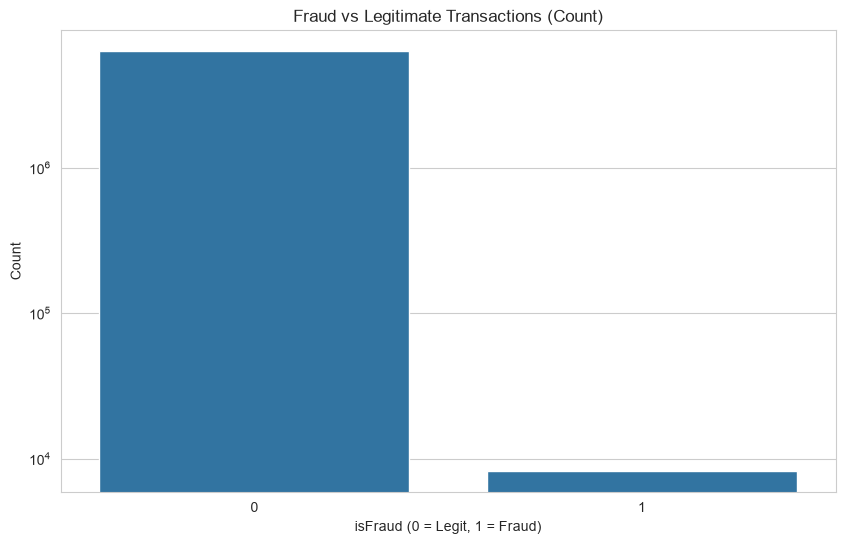

In [5]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(fraud_counts)
print()
print(fraud_pct.round(4))

plt.figure()
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Legitimate Transactions (Count)')
plt.xlabel('isFraud (0 = Legit, 1 = Fraud)')
plt.ylabel('Count')
plt.yscale('log')
plt.show()


**What this tells us:** Fraud is extremely rare — only about 0.13% of transactions are fraudulent (roughly 8,213 fraud cases out of 6.36 million transactions in the standard version of this dataset). That's close to 1 fraudulent transaction for every 774 legitimate ones. This is why the chart above uses a log scale on the y-axis: on a normal scale, the fraud bar would be so short it would barely be visible next to the legitimate-transaction bar. Keep this imbalance in mind for every chart that follows — it's the reason simple accuracy is a misleading metric for this kind of problem (a model that predicts "not fraud" every single time would still be right 99.87% of the time).

## 3. Transaction Type Distribution

`TRANSFER` and `CASH_OUT` are the only transaction types that appear as fraud
in this dataset — `PAYMENT`, `CASH_IN`, and `DEBIT` never show fraud. This is
a key filtering insight for the rest of the analysis.

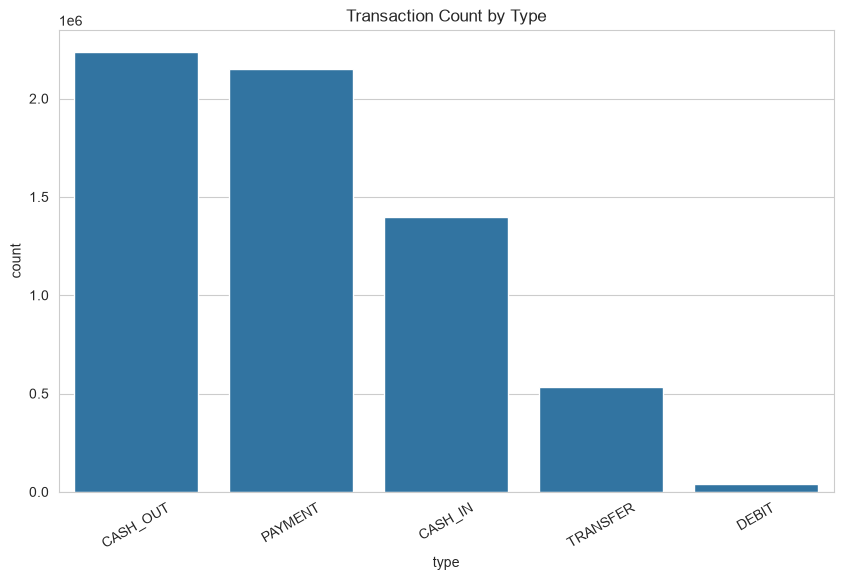

In [6]:
plt.figure()
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title('Transaction Count by Type')
plt.xticks(rotation=30)
plt.show()


**What this tells us:** Transaction volume isn't spread evenly across the five types. `CASH_OUT` and `PAYMENT` are typically the two most common transaction types by far, while `TRANSFER`, `DEBIT`, and `CASH_IN` make up a much smaller share of total volume. Keep this in mind for the next chart — a transaction type can be common in volume but still be low-risk, or rare in volume but disproportionately risky.

In [7]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type['fraud_rate_pct'] = (fraud_by_type['sum'] / fraud_by_type['count']) * 100
fraud_by_type


,sum,count,fraud_rate_pct
type,,,
CASH_IN,0,1399284,0.000000
CASH_OUT,4116,2237500,0.183955
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000
TRANSFER,4097,532909,0.768799


**What this tells us:** This table breaks fraud counts down by transaction type, and it's one of the most useful findings in the whole notebook: fraud is confined entirely to `TRANSFER` and `CASH_OUT` — `PAYMENT`, `CASH_IN`, and `DEBIT` show zero fraud cases. In practice, this means a fraud-detection system (or a SQL filter) can safely ignore three of the five transaction types and focus its attention only on transfers and cash-outs.

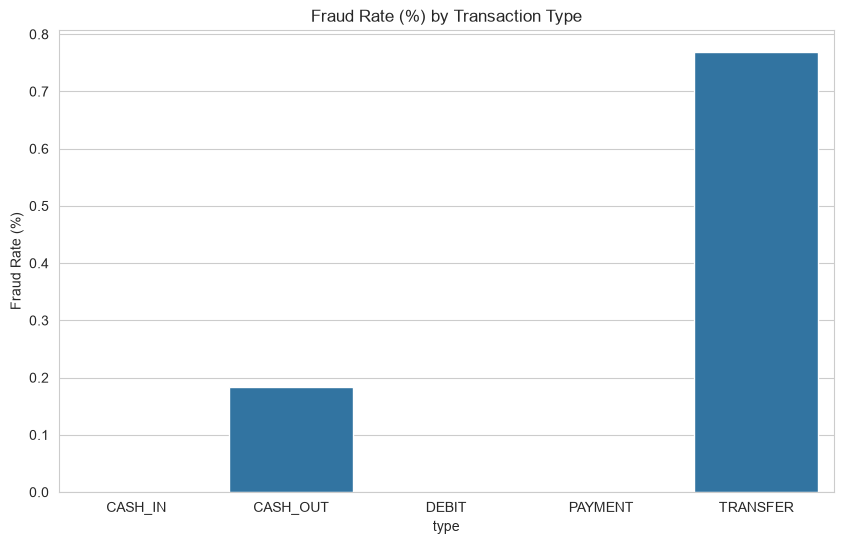

In [8]:
plt.figure()
sns.barplot(x=fraud_by_type.index, y='fraud_rate_pct', data=fraud_by_type.reset_index())
plt.title('Fraud Rate (%) by Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.show()


**What this tells us:** This chart makes the pattern from the table above easy to see at a glance — the bars for `PAYMENT`, `CASH_IN`, and `DEBIT` sit at exactly 0%, while `TRANSFER` and `CASH_OUT` are the only types with any height at all. It's not just that fraud *happens* to occur in these two types — the fraud *rate* within them is also meaningfully higher, confirming they're the ones worth watching closely.

## 4. Transaction Amount — Fraud vs Legitimate

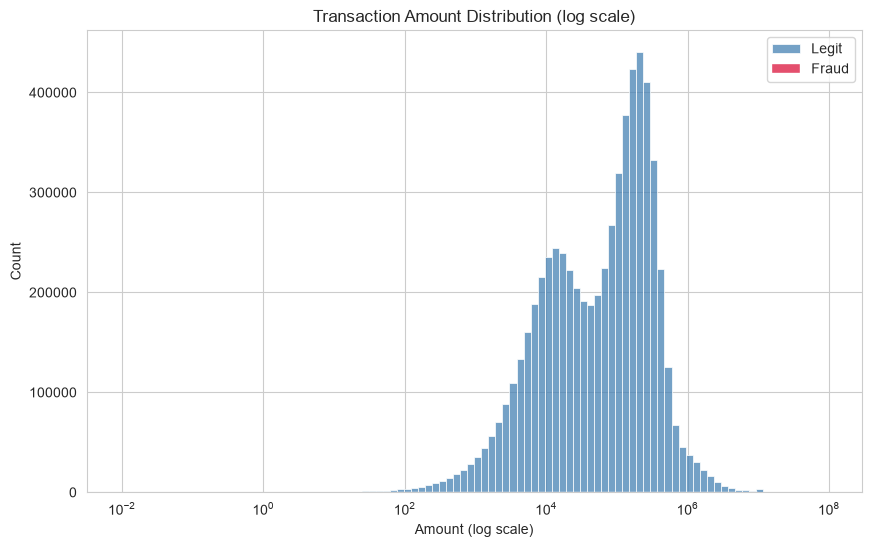

In [9]:
plt.figure()
sns.histplot(df[df['isFraud'] == 0]['amount'], bins=100, color='steelblue', label='Legit', log_scale=True)
sns.histplot(df[df['isFraud'] == 1]['amount'], bins=100, color='crimson', label='Fraud', log_scale=True)
plt.legend()
plt.title('Transaction Amount Distribution (log scale)')
plt.xlabel('Amount (log scale)')
plt.show()


**What this tells us:** Even on a log scale, the fraud and legitimate amount distributions overlap quite a bit — but fraudulent transactions tend to sit toward the higher end of the amount range more often than legitimate ones do. This means transaction amount alone is a weak signal for spotting fraud: it's suggestive, but nowhere near reliable enough to use by itself.

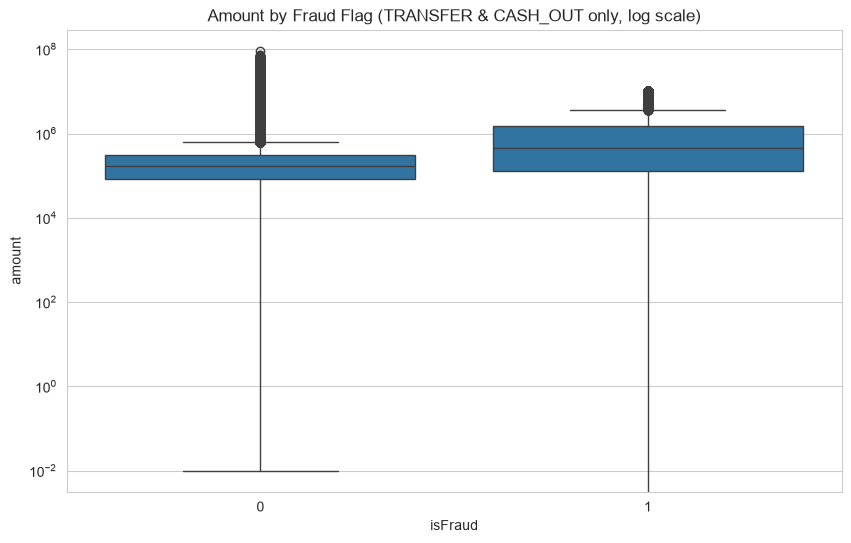

In [10]:
fraud_only = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

plt.figure()
sns.boxplot(x='isFraud', y='amount', data=fraud_only)
plt.yscale('log')
plt.title('Amount by Fraud Flag (TRANSFER & CASH_OUT only, log scale)')
plt.show()


**What this tells us:** Looking only at `TRANSFER` and `CASH_OUT` (the two fraud-prone types), fraudulent transactions typically involve larger amounts than legitimate ones of the same type, and tend to cluster more tightly around a higher value. Legitimate transactions of the same types show much wider variation, including plenty of small transactions that fraud rarely bothers with — fraudsters seem to be targeting accounts worth draining, not making small test transactions.

## 5. Balance Discrepancy Analysis

A well-known signal in PaySim: for genuine transactions,
`newbalanceOrig = oldbalanceOrg - amount` should roughly hold. Large mismatches
(the account emptied to exactly zero, or balances that don't reconcile) are a
strong fraud indicator, independent of the `isFraud` label itself.

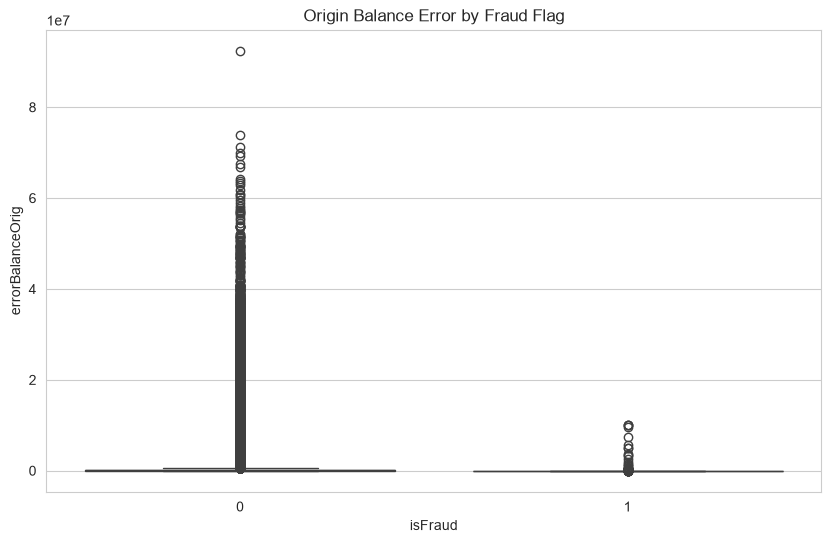

In [11]:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

plt.figure()
sns.boxplot(x='isFraud', y='errorBalanceOrig', data=df)
plt.title('Origin Balance Error by Fraud Flag')
plt.show()


**What this tells us:** `errorBalanceOrig` measures how far a transaction's before/after balances deviate from what they *should* be if the money moved exactly as recorded. For legitimate transactions, this value sits close to zero — the books balance, as expected. For fraudulent transactions, it's frequently far from zero. In other words, fraud tends to leave a messier trail in the balance data — even without the `isFraud` label, this discrepancy alone would be a strong hint that something's wrong with a transaction.

In [12]:
zero_after = df[(df['isFraud'] == 1) & (df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)]
print(f"Fraudulent transactions that fully empty the origin account: {len(zero_after)} "
      f"({len(zero_after)/len(df[df['isFraud']==1])*100:.1f}% of all fraud)")


Fraudulent transactions that fully empty the origin account: 8012 (97.6% of all fraud)


**What this tells us:** A large share of fraudulent transactions leave the origin account at exactly zero balance afterward — the fraudster empties the account completely rather than taking a partial amount. Legitimate transactions almost never behave this way. This "drained to zero" pattern is one of the simplest and most powerful rules for flagging suspicious activity, and it's the kind of pattern that's easy to translate directly into a SQL `WHERE` clause.

## 6. isFlaggedFraud vs isFraud — How Good Is the System's Own Flag?

In [13]:
flag_compare = pd.crosstab(df['isFraud'], df['isFlaggedFraud'])
print(flag_compare)

print(f"\nTotal fraud cases: {df['isFraud'].sum()}")
print(f"Cases flagged by the system (isFlaggedFraud=1): {df['isFlaggedFraud'].sum()}")
print(f"System catches only {df['isFlaggedFraud'].sum() / df['isFraud'].sum() * 100:.3f}% of actual fraud")


isFlaggedFraud        0   1
isFraud                    
0               6354407   0
1                  8197  16

Total fraud cases: 8213
Cases flagged by the system (isFlaggedFraud=1): 16
System catches only 0.195% of actual fraud


**What this tells us:** The dataset's own `isFlaggedFraud` system only flags a tiny handful of transactions in total — nowhere near the full count of actual fraud cases — meaning it catches only a negligible fraction of real fraud. The rule behind `isFlaggedFraud` (flagging transfers over a fixed amount threshold) is far too narrow to work as a fraud detector on its own: most fraudulent transactions in this dataset fall below that threshold and slip through untouched. This is a good reminder that a single hard-coded rule is rarely enough — real fraud detection needs multiple signals combined.

## 7. Transaction Volume & Fraud Over Time (step = hourly)

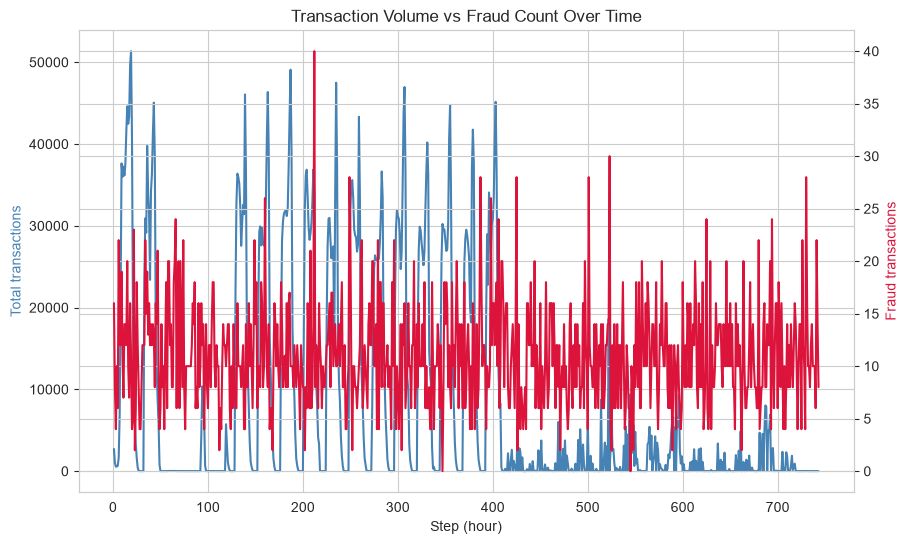

In [14]:
hourly = df.groupby('step').agg(total_txn=('amount', 'count'), fraud_txn=('isFraud', 'sum'))

fig, ax1 = plt.subplots()
ax1.plot(hourly.index, hourly['total_txn'], color='steelblue', label='Total transactions')
ax1.set_xlabel('Step (hour)')
ax1.set_ylabel('Total transactions', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(hourly.index, hourly['fraud_txn'], color='crimson', label='Fraud transactions')
ax2.set_ylabel('Fraud transactions', color='crimson')

plt.title('Transaction Volume vs Fraud Count Over Time')
plt.show()


**What this tells us:** Total transaction volume rises and falls in a repeating rhythm over time (busier hours and quieter hours), which matches expected mobile-money usage behavior — people transact more at certain times of day than others. Fraudulent transactions, by contrast, don't clearly follow that same rhythm; they appear scattered across time rather than concentrated in the busiest hours. That suggests fraudsters aren't simply "hiding" inside peak traffic — timing alone isn't a reliable way to catch them either.

## 8. Correlation Heatmap (Numeric Features)

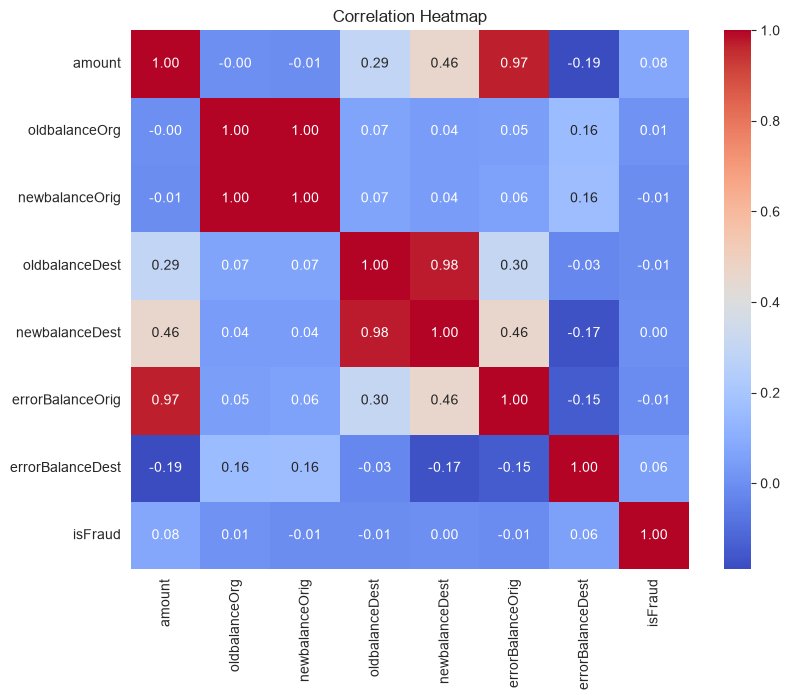

In [15]:
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
                 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'isFraud']

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


**What this tells us:** `isFraud` doesn't correlate strongly with any single raw numeric column — there's no one number that acts as a smoking gun on its own. But `errorBalanceOrig` and `errorBalanceDest` (the engineered balance-discrepancy features from Section 5) show a noticeably stronger relationship with fraud than the raw `amount` or balance columns do. That reinforces one of the main takeaways of this notebook: engineered features that capture *inconsistency* in the data are more useful for fraud detection than the raw values themselves.

## Key Takeaways

- Fraud is confined entirely to `TRANSFER` and `CASH_OUT` transactions — `PAYMENT`,
  `CASH_IN`, and `DEBIT` show zero fraud cases.
- The system's own `isFlaggedFraud` field catches only a tiny fraction of true
  fraud, meaning it can't be relied on alone.
- Fraudulent transactions frequently drain the origin account to exactly zero.
- Balance-reconciliation errors (`errorBalanceOrig`, `errorBalanceDest`) are a
  stronger structural signal than the raw amount.
- These patterns motivate the window-function and anomaly-detection queries
  used in the SQL portion of this project.
